# **Import Modules**

In [1]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# **Load The Dataset**

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e9/train.csv')

test = pd.read_csv('/kaggle/input/playground-series-s5e9/test.csv')

# **Data Understanding**

In [3]:
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [4]:
test.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [6]:
train.shape

(524164, 11)

In [7]:
train.columns

Index(['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
       'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
       'TrackDurationMs', 'Energy', 'BeatsPerMinute'],
      dtype='object')

In [8]:
train['BeatsPerMinute'].value_counts()

BeatsPerMinute
103.80132    82
136.47533    79
99.74389     78
132.77461    71
112.34526    71
             ..
129.11132    17
143.19594    17
99.12850     16
134.15182    16
160.30977    13
Name: count, Length: 14622, dtype: int64

In [9]:
train.duplicated().sum()

0

# HeatMap

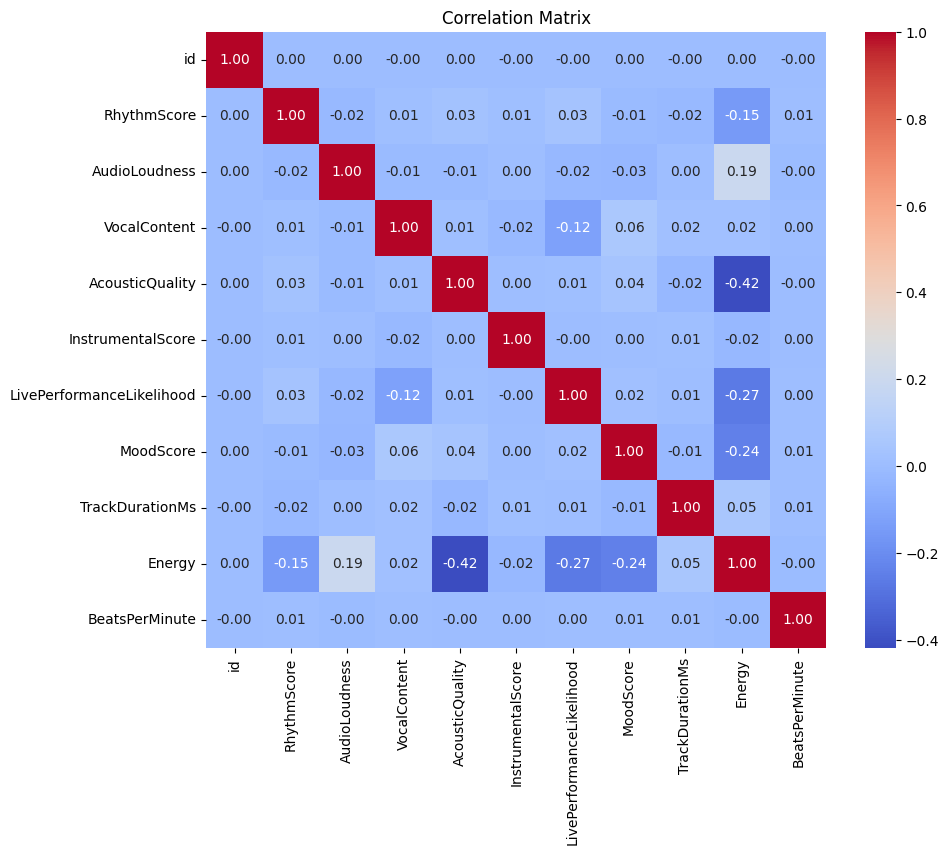

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

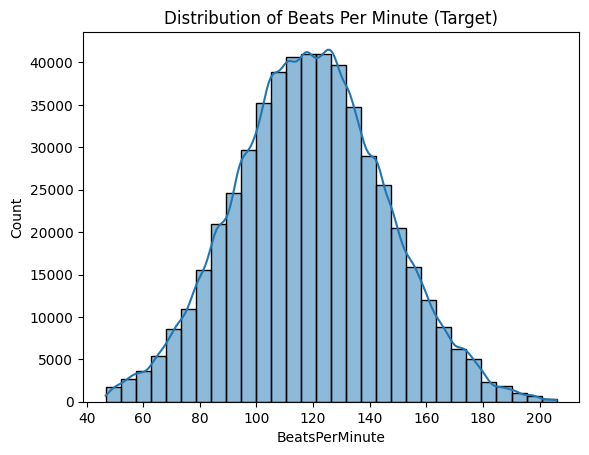

In [11]:
# Quick distribution
sns.histplot(train["BeatsPerMinute"], kde=True, bins=30)
plt.title("Distribution of Beats Per Minute (Target)")
plt.show()

# **Data Preprocessing**

In [12]:
X = train.drop(columns=['id', 'BeatsPerMinute'])

y = train['BeatsPerMinute']

X_test_final = test.drop(columns=['id'])

In [13]:
num_columns = X.columns.tolist()

In [14]:
numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_columns)
    ],
    remainder="drop"
)




In [15]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


# Helper Functions

In [16]:
def evaluate_model(model, X_train, y_train, X_valid, y_valid, name):
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_valid)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    r2 = r2_score(y_valid, y_pred)

    print(f"\n--- {name} ---")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE : {mae:.3f}")
    print(f"R²  : {r2:.3f}")

    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# **Model Building**

# Decision Tree

In [17]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [18]:
dt_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['RhythmScore',
                                                   'AudioLoudness',
                                                   'VocalContent',
                                                   'AcousticQuality',
                                                   'InstrumentalScore',
                                                   'LivePerformanceLikelihood',
                                                   'MoodScore',
                                                   'TrackDurationMs',
                                                   'Energy'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [19]:
y_pred = dt_pipe.predict(X_valid)

In [20]:
#Metrics
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)


print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

RMSE: 38.293
MAE : 30.657
R²  : -1.097


# XGBoost

In [21]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

# LightGBM

In [22]:
lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(random_state=42))
])

# Linear Regression

In [23]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [24]:
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['RhythmScore',
                                                   'AudioLoudness',
                                                   'VocalContent',
                                                   'AcousticQuality',
                                                   'InstrumentalScore',
                                                   'LivePerformanceLikelihood',
                                                   'MoodScore',
                                                   'TrackDurationMs',
                                                   'Energy'])])),
                ('model', LinearRegression())])

In [25]:
y_pred = lr_pipe.predict(X_valid)

In [26]:
#Metrics
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)


print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

RMSE: 26.444
MAE : 21.184
R²  : 0.000


# Random Forest

In [27]:
rf_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42, max_depth= 3))
])

In [28]:
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['RhythmScore',
                                                   'AudioLoudness',
                                                   'VocalContent',
                                                   'AcousticQuality',
                                                   'InstrumentalScore',
                                                   'LivePerformanceLikelihood',
                                                   'MoodScore',
                                                   'TrackDurationMs',
                                                   'Energy'])])),
                ('model',
                 RandomForestRegressor(max_depth=3, n_estimators=200, n_jobs=-1,
                                       random_state=42))])

# **Model Evaluation**

In [29]:
# ============================
# 📊 Collect Results
# ============================
models = [
    ("Linear Regression", lr_pipe),
    ("Decision Tree", dt_pipe),
    ("Random Forest", rf_pipe),
    ("XGBoost", xgb_pipe),
    ("LightGBM", lgbm_pipe)
]

results = []
for name, model in models:
    res = evaluate_model(model, X_train, y_train, X_valid, y_valid, name)
    results.append(res)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)



--- Linear Regression ---
RMSE: 26.444
MAE : 21.184
R²  : 0.000

--- Decision Tree ---
RMSE: 38.293
MAE : 30.657
R²  : -1.097

--- Random Forest ---
RMSE: 26.440
MAE : 21.181
R²  : 0.000

--- XGBoost ---
RMSE: 26.553
MAE : 21.274
R²  : -0.008
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 419331, number of used features: 9
[LightGBM] [Info] Start training from score 119.056554

--- LightGBM ---
RMSE: 26.443
MAE : 21.186
R²  : 0.000

Model Comparison:
               Model       RMSE        MAE        R2
0  Linear Regression  26.443880  21.184139  0.000095
1      Decision Tree  38.293339  30.656598 -1.096790
2      Random Forest  26.439825  21.180825  0.000402
3            XGBoost  26.553388  21.273981 -0.008204
4           LightGBM  26.443291  21.185833  0.000139


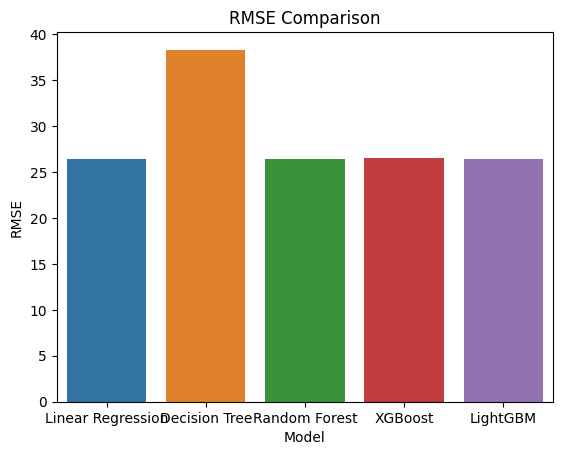

In [30]:
# checking which one RMSE is low

sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("RMSE Comparison")
plt.show()

**Among All the models we use Random Forest**

In [31]:
#best_model = lr_pipe

#cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [32]:
#cv_scores

In [33]:
#best_model.fit(X, y)


In [34]:
#preds = best_model.predict(X_test_final)

# **Final Model Training & Prediction**

In [35]:
best_model = rf_pipe

best_model.fit(X, y)

#cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['RhythmScore',
                                                   'AudioLoudness',
                                                   'VocalContent',
                                                   'AcousticQuality',
                                                   'InstrumentalScore',
                                                   'LivePerformanceLikelihood',
                                                   'MoodScore',
                                                   'TrackDurationMs',
                                                   'Energy'])])),
                ('model',
                 RandomForestRegressor(max_depth=3, n_estimators=200, n_jobs=-1,
                                       random_state=42))])

# **Predict on Test Data**

In [36]:
preds = best_model.predict(X_test_final)

# **Final Submission**

In [37]:
#submission = pd.DataFrame({
#    "id": test["id"],
#    "BeatsPerMinute": preds
#})
#
#submission.to_csv("submission.csv", index=False)
#print("✅ submission.csv saved!")

In [38]:
submission = pd.DataFrame({
    "id": test["id"],
    "BeatsPerMinute": preds
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved!")

✅ submission.csv saved!
